In [60]:
from model_builder import ModelBuilder
from model_builder_keras import ModelBuilder as KerasModelBuilder

from preprocessing import Preprocessor
from plotting_other import Plotter
from plotting import plot_dataset
#from shapley import ProcessAttributor
from shapley_improved import ProcessAttributorSHAP
from shapley_improved import ProcessAttributorEBM
from shapley_improved_other import ProcessAttributorSHAPMLP

from universal_filtering import CustomSpearmanFilter
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
#from sklearn.linear_model import Ridge
#from sklearn.linear_model import Lasso
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np

# Basic Deep Learning with Sklearn MLP
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance

# Deep Learning with Keras Tensorflow
import keras
from keras import layers, optimizers, callbacks, Sequential
#https://ipython.org/ipython-doc/3/config/extensions/autoreload.html
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
train_sarek = [
    pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260701T215234Z/datasets/sarek_1_0207.parquet"),
    pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260702T193504Z/datasets/sarek_2_0207.parquet")
]
test_sarek = pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260708T212252Z/datasets/sarek3_0907.parquet")


In [62]:
training_data = pd.concat(train_sarek, ignore_index=True)
training_data = training_data
test_data = test_sarek
PNG_NAME = "mlp_pred_sarek"

features = [
    "delta_cpu_ns",
    "delta_io_bytes",
    "delta_net_send_bytes",
    "context_switches",
    "syscall_count",
    "delta_rss_memory",
    "delta_cpu_time_psutil",
    "delta_cpu_time_proc",
    "syscall_class_file",
    "syscall_class_network",
    "syscall_class_memory",
    "syscall_class_process",
    "syscall_class_other",
    "syscall_class_sched",
    "syscall_class_signal",
    "syscall_class_time",
    "delta_cycles",
    "delta_cache_misses",
    "delta_instructions",
    "delta_branch_instructions",
]


In [63]:
preprocessor_train = Preprocessor(training_data, features)
X_train_FULL, y_train, t_train, _ = preprocessor_train.preprocess_no_split()

Dropped 0 timestamps.


In [64]:
#plot_dataset(t_train, y_train, "multi_training")


In [65]:
#build_model = ExplainableBoostingRegressor( interactions=2, max_rounds=2000, n_jobs=-1, random_state=42)
model = RandomForestRegressor(n_estimators=100,  n_jobs=-1, random_state=42)
#build_model = MLPRegressor(activation="relu", solver="adam", random_state=42)



In [66]:
#These thresholds could be fine tuned
automatic_feature_selection = Pipeline(steps=[
    ('variance', VarianceThreshold(threshold=0.01)), #explain this

    ('decorrelate', CustomSpearmanFilter(threshold=0.80)),
    ('scaler', StandardScaler()),
    ('select_features', SelectFromModel(model, threshold='0.5*median'))
])

automatic_feature_selection.set_output(transform="pandas")
automatic_feature_selection.fit_transform(X_train_FULL, y_train)
good_features = automatic_feature_selection.get_feature_names_out().tolist()
X_train = X_train_FULL[good_features]
print("Selected columns:")
print(good_features)


#plot_dataset(t_train, y_train, "multi_training")

Selected columns:
['delta_cpu_ns', 'delta_io_bytes', 'delta_net_send_bytes', 'context_switches', 'syscall_count', 'delta_rss_memory', 'delta_cpu_time_proc', 'syscall_class_file', 'syscall_class_network', 'syscall_class_memory', 'syscall_class_process', 'syscall_class_other']


In [67]:
preprocessor_test = Preprocessor(test_data, good_features)
X_test, y_test, t_test , X_test_unaggregated = preprocessor_test.preprocess_no_split()

#plot_dataset(t_test, y_test, "multi_testing")

Dropped 0 timestamps.


In [68]:
plot_dataset(t_test, y_test, "multi_testing")

### Sklearn MLP

In [69]:
build_model_mlp = MLPRegressor(hidden_layer_sizes=(128,32,16),
                    activation='relu',
                    solver='adam',
                    learning_rate_init=0.0001,
                    max_iter=500,
                    #alpha = 0.0000675,
                    batch_size=64,
                    early_stopping=True,    # Crucial for time-series stability
                    #validation_fraction=0.1,
                    random_state=42)

In [70]:
builder = ModelBuilder(X_train, X_test, y_train, y_test, build_model_mlp, StandardScaler())
y_pred, learned_idle_power = builder.run_and_save_model()


  R² Score:  0.9064
  MAE:       6.05 Ws (3.01% of mean)
----------------------------------
The model's learned baseline idle interval energy is: 143.88 Ws
----------------------------------
/n


In [71]:
plotter = Plotter(y_pred,y_test, t_test,"mlp")#, window_start =50, window_end=200)
plotter.plot_and_save("", PNG_NAME)

In [72]:
#check if we ann pass this differently
#attributor = ProcessAttributorSHAPMLP( builder.X_test_scaled, builder.model, builder.scaler)
#attributor.attribute(X_test_unaggregated,good_features,t_test.values, "mlp_graphs_")

### Deep Learning with Keras

Build the 1D-CNN in Keras (Tutorials)

- https://keras.io/guides/sequential_model/
- https://keras.io/examples/timeseries/timeseries_classification_from_scratch/
- https://www.tensorflow.org/tutorials/structured_data/time_series#recurrent_neural_network
- https://keras.io/examples/timeseries/timeseries_classification_from_scratch/



In [73]:
num_features = len(good_features)

In [83]:
# Models used
# Convolutional Neural Network (1D)
cnn_model = Sequential([

    layers.Input(shape=(num_features, 1)), # (num_features, sequence_length) #Only current value
    layers.Conv1D(32, kernel_size=num_features, padding='same', activation="relu"),
    layers.BatchNormalization(),

    layers.Conv1D(32, kernel_size=num_features, padding='same', activation="relu"),
    layers.BatchNormalization(),

    #layers.Conv1D(32, kernel_size=num_features, padding='same', activation="relu"),
    #layers.BatchNormalization(),
    
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
    
])

# Feed Forward Neural Network
ffnn_model = Sequential([
    layers.Input(shape=(num_features, 1)), # (num_features, sequence_length) #Only current value
    layers.Flatten(),
    #layers.GlobalAveragePooling1D(),
    #layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    #layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
    
])

# LSTM Model
lstm_model = Sequential([
    layers.Input(shape=(num_features, 1)), # (num_features, sequence_length) #Only current value
    layers.BatchNormalization(),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(64, return_sequences=True),
    layers.Flatten(),
    #layers.GlobalAveragePooling1D(),
    #layers.Dropout(0.2),
    #layers.Dense(32, activation='relu'),
    layers.Dense(1)
    
])

In [75]:
builder_lstm = KerasModelBuilder(X_train, X_test, y_train, y_test, lstm_model, StandardScaler())
y_pred_lstm, learned_idle_power = builder_lstm.run_and_save_model()

Epoch 1/30


209/209 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 17530.0059 - mae: 118.9175 - val_loss: 870.7816 - val_mae: 28.2156
Epoch 2/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1127.4424 - mae: 23.4114 - val_loss: 167.9311 - val_mae: 11.7083
Epoch 3/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 424.1759 - mae: 14.7748 - val_loss: 151.9164 - val_mae: 10.4036
Epoch 4/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 301.8724 - mae: 11.7969 - val_loss: 109.2576 - val_mae: 7.7267
Epoch 5/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 254.5428 - mae: 10.0740 - val_loss: 92.7064 - val_mae: 6.9336
Epoch 6/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 240.3714 - mae: 9.4415 - val_loss: 83.8187 - val_mae: 6.1145
Epoch 7/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 235.6614 - mae: 9.2917 - val_loss: 83.3792 - val_mae: 6.0874
Epoch 8/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 235.0394 - mae: 9.2202 - val_loss: 79.9446 - val_mae: 5.7080
Epoch 9/30
209/209 

In [76]:
#plotter = Plotter(y_pred=y_pred_lstm,y_test=y_test, t_test= t_test,alg_name="lstm",window_start=150, window_end=200)
plotter = Plotter(y_pred=y_pred_lstm,y_test=y_test, t_test= t_test,alg_name="lstm")
#plotter.plot_only("lstm_")
plotter.plot_and_save("ltsm_")

In [78]:
builder_cnn = KerasModelBuilder(X_train, X_test, y_train, y_test, cnn_model, StandardScaler())
y_pred_cnn, learned_idle_power = builder_cnn.run_and_save_model()

Epoch 1/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 13711.3984 - mae: 85.6304 - val_loss: 6799.0259 - val_mae: 82.1042
Epoch 2/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 154.3759 - mae: 8.7519 - val_loss: 842.9647 - val_mae: 28.4079
Epoch 3/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 122.6271 - mae: 7.7166 - val_loss: 79.8415 - val_mae: 7.0982
Epoch 4/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 106.2302 - mae: 7.1156 - val_loss: 45.7780 - val_mae: 4.1740
Epoch 5/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 95.5532 - mae: 6.6797 - val_loss: 55.6755 - val_mae: 4.9830
Epoch 6/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 93.1525 - mae: 6.7220 - val_loss: 57.2292 - val_mae: 5.1020
Epoch 7/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 90.7767 - mae: 6.5285 - val_loss: 44.9857 - val_mae: 4.5536
Epoch 8/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 89.5322 - mae: 6.4457 - val_loss: 39.4042 - val_mae: 4.0695
Epoch 9/30
209/209 ━━━━━━━━━

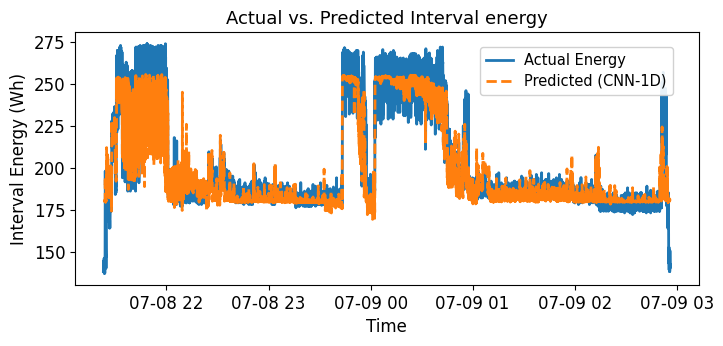

In [79]:
plotter = Plotter(y_pred=y_pred_lstm,y_test=y_test, t_test= t_test,alg_name="cnn_1d")
plotter.plot_only("cnn_1d")
#plotter.plot_and_save("cnn_1d_")

In [85]:
#64-16 # Faster other models
#  R² Score:  0.9224
#  MAE:       5.53 Ws (2.75% of mean)
builder_ffnn1 = KerasModelBuilder(X_train, X_test, y_train, y_test, ffnn_model, StandardScaler())
y_pred_ffnn1, learned_idle_power = builder_cnn.run_and_save_model()

Epoch 1/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 69.0502 - mae: 5.5695 - val_loss: 34.9031 - val_mae: 4.2573
Epoch 2/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 67.6853 - mae: 5.5500 - val_loss: 31.3207 - val_mae: 3.6544
Epoch 3/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 69.0121 - mae: 5.6195 - val_loss: 33.4936 - val_mae: 3.7915
261/261 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  R² Score:  0.9022
  MAE:       6.24 Ws (3.10% of mean)
----------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
The model's learned baseline idle interval energy is: 127.39 Ws
----------------------------------
/n


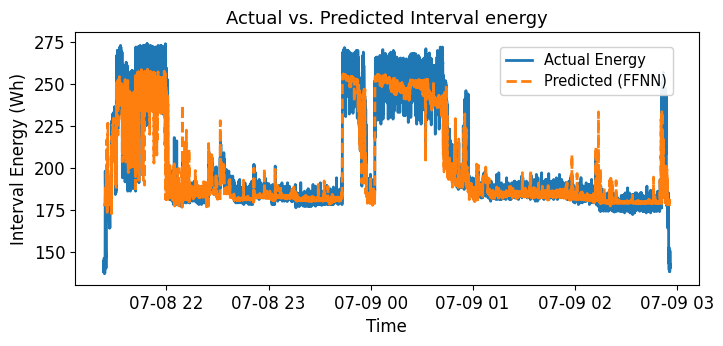

In [ ]:
plotter = Plotter(y_pred=y_pred_lstm,y_test=y_test, t_test= t_test,alg_name="ffnn")
plotter.plot_only("ffnn_")
plotter.plot_and_save("ffnn_")